<a href="https://colab.research.google.com/github/SteaveRkt/analysis-asos-products-data/blob/main/analysis/analyse_asos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [247]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [248]:
racine=Path("/")
try:
  chemin_csv=next(racine.rglob("products_asos.csv"),None)
  chemin=chemin_csv.resolve()
  df=pd.read_csv(chemin,on_bad_lines="skip")
  df.head()
except:
  print("Le fichier n'existe pas")


In [249]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30845 entries, 0 to 30844
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   url          30827 non-null  object 
 1   name         30827 non-null  object 
 2   size         30827 non-null  object 
 3   category     30827 non-null  object 
 4   price        30827 non-null  object 
 5   color        30827 non-null  object 
 6   sku          30827 non-null  float64
 7   description  30827 non-null  object 
 8   images       30827 non-null  object 
dtypes: float64(1), object(8)
memory usage: 2.1+ MB


In [250]:
df['price'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 30845 entries, 0 to 30844
Series name: price
Non-Null Count  Dtype 
--------------  ----- 
30827 non-null  object
dtypes: object(1)
memory usage: 241.1+ KB


In [251]:
df['price']=pd.to_numeric(df['price'],errors='coerce')
df=df.dropna(subset=['price'])
df['category']=df['category'].astype(str)
def split (text):
  try:
    return text.split(" ")[0]
  except:
    return "Unknown"
df['brand']=df['category'].apply(split)
df.tail(5)

,url,name,size,category,price,color,sku,description,images,brand
30840,https://www.asos.com/urban-revivo/urban-revivo...,Urban Revivo square neck mini dress in floral ...,"XS - UK 6 - Out of stock,S - UK 8 - Out of sto...",Urban Revivo square neck mini dress in floral ...,44.00,Multi,116745746.0,[{'Product Details': 'Mini dress by Urban Revi...,['https://images.asos-media.com/products/urban...,Urban
30841,https://www.asos.com/asos-design/asos-design-l...,ASOS DESIGN long sleeve maxi t-shirt dress in ...,"UK 4 - Out of stock,UK 6 - Out of stock,UK 8 -...",ASOS DESIGN long sleeve maxi t-shirt dress in ...,24.00,Black,1444255.0,[{'Product Details': 'Dress by ASOS DESIGN Act...,['https://images.asos-media.com/products/asos-...,ASOS
30842,https://www.asos.com/asyou/asyou-layered-t-shi...,ASYOU layered t-shirt dress with focus graphic...,"UK 4 - Out of stock,UK 6,UK 8 - Out of stock,U...",ASYOU layered t-shirt dress with focus graphic...,22.99,Washed black,110783769.0,[{'Product Details': 'Dress by ASYOU Exclusive...,['https://images.asos-media.com/products/asyou...,ASYOU
30843,https://www.asos.com/miss-selfridge/miss-selfr...,Miss Selfridge Petite rib knit frill hem funne...,"UK 4 - Out of stock,UK 6 - Out of stock,UK 8 -...",Miss Selfridge Petite rib knit frill hem funne...,32.99,BLACK,116363729.0,[{'Product Details': 'Petite by Miss Selfridge...,['https://images.asos-media.com/products/miss-...,Miss
30844,https://www.asos.com/other-stories/other-stori...,& Other Stories plisse mesh midi dress in blac...,"XS - UK 4-6 - Out of stock,S - UK 8-10,M - UK ...",& Other Stories plisse mesh midi dress in blac...,65.00,Black and white,124159122.0,[{'Product Details': 'Dresses by & Other Stori...,['https://images.asos-media.com/products/other...,&


In [252]:
brand_map={
    "New":"New Look",
    "River":"River Island",
    "TopshopWelcome":"Topshop",
    "&":"Unknown"
}

df['brand']=df['brand'].map(brand_map).fillna(df['brand'])
brand_counts=df['brand'].value_counts()
valid_brands=brand_counts[brand_counts>10]
df_clean=df[df['brand'].isin(valid_brands.index)].copy()
df_clean['brand'].value_counts().head(5)

,count
brand,
ASOS,4842
Topshop,1136
New Look,509
River Island,474
Miss,429


In [253]:
def calculate_phantom_revenue(size_str):
  if not isinstance(size_str,str):
    return 0,0.0
  total_sizes=len(size_str.split(","))
  total_out_of_stock=size_str.count("Out of stock")
  rate=total_out_of_stock/total_sizes if total_sizes>0 else 0.0
  return total_out_of_stock,rate
metrics=df_clean['size'].apply(calculate_phantom_revenue)
df_clean['Stockout_count']=metrics.apply(lambda x:x[0])
df_clean['Stockout_rate']=metrics.apply(lambda x:x[1])
df_clean['lost_revenue']=df_clean['price']*df_clean['Stockout_count']
cols=['brand','name','price','Stockout_count','lost_revenue']
df_clean.sort_values('lost_revenue',ascending=False)[cols].head(5)

,brand,name,price,Stockout_count,lost_revenue
2941,Barbour,Barbour Beadnell wax jacket in black,219.0,9,1971.0
2679,Barbour,Barbour x ASOS exclusive Stephanie wax parka i...,279.0,7,1953.0
3192,AllSaints,AllSaints Elora leather biker jacket in black,319.0,6,1914.0
21948,Topshop,Topshop premium real leather collared zip thro...,260.0,7,1820.0
2715,ASOS,ASOS DESIGN premium real leather trench coat i...,220.0,7,1540.0


In [254]:
brand_strategy=df_clean.groupby('brand').agg({
    'name':'count',
    'Stockout_rate':'mean',
    'lost_revenue':'sum',
    'price':'mean'
}).reset_index()
brand_strategy=brand_strategy[brand_strategy['name']>10]
brand_strategy

,brand,name,Stockout_rate,lost_revenue,price
0,4th,40,0.308333,2850.00,41.750000
1,AFRM,45,0.100882,2015.00,64.511111
2,ASOS,4842,0.279126,472307.00,46.530463
3,ASYOU,252,0.214672,11430.45,28.422540
4,AX,14,0.178571,615.00,44.785714
...,...,...,...,...,...
137,Wonderbra,11,0.468815,6157.00,41.545455
138,Y.A.S,92,0.203986,7411.00,78.336957
139,Yours,121,0.360632,7964.76,27.771322
140,adidas,394,0.233658,29048.00,48.190355


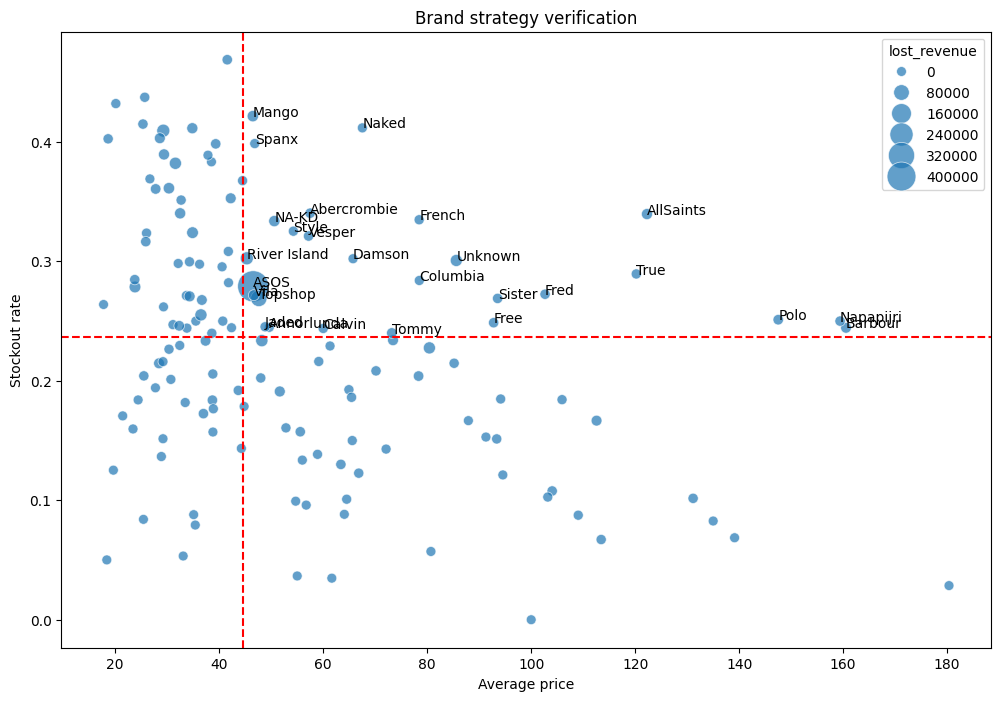

0.23691525423728815 2966.92


In [255]:
rate_median=brand_strategy['Stockout_rate'].median()
price_median=brand_strategy['price'].median()
winners=brand_strategy[(brand_strategy['Stockout_rate']>(brand_strategy['Stockout_rate'].median()))&(brand_strategy['price']>(brand_strategy['price'].median()))]
plt.figure(figsize=(12,8))
sns.scatterplot(data=brand_strategy,x='price',y='Stockout_rate',size='lost_revenue',sizes=(50,500),alpha=0.7)
for i in range(len(winners)):
  plt.text(x=winners['price'].iloc[i],y=winners['Stockout_rate'].iloc[i],s=winners['brand'].iloc[i])
plt.title('Brand strategy verification')
plt.xlabel('Average price')
plt.ylabel('Stockout rate')
plt.axvline(x=price_median,linestyle='--',color='red')
plt.axhline(y=rate_median,linestyle='--',color='red')
plt.show()
print(rate_median,revenue_median)

In [256]:
winners

,brand,name,Stockout_rate,lost_revenue,price
2,ASOS,4842,0.279126,472307.00,46.530463
5,Abercrombie,48,0.340341,5702.00,57.479167
6,AllSaints,56,0.339598,14228.00,122.267857
10,Annorlunda,32,0.244792,2413.00,49.625000
14,Barbour,32,0.244382,10043.60,160.550000
20,Calvin,53,0.243868,3533.00,60.000000
26,Columbia,25,0.284000,2144.00,78.480000
29,Damson,15,0.302222,1567.00,65.733333
42,Fred,36,0.272487,5069.00,102.666667
43,Free,49,0.248639,5425.98,92.775306
